# JAX distributed arrays, from a halo-exchange point of view

*Companion to `nb02_distributed_ad.ipynb`, which uses `shard_map` and `ppermute`
without explaining where they come from. This notebook is that explanation.*

A `jax.Array` can live on one device or on ten thousand. The array's *value* is global —
you index it, reduce it, print it as if it were one NumPy array — while its *storage* is
split across devices according to a **sharding**. Everything interesting follows from a
single question: when the program asks for a value that lives on another device, who
decides to move it, and how much gets moved?

For a weather model that question has a name: the **halo exchange**. So rather than tour
the API, this notebook keeps asking one thing — *what communication does a nearest-neighbour
stencil actually generate?* — and uses it to pull in the machinery.

> **Environment.** This notebook needs **JAX ≥ 0.11** and Python ≥ 3.12, which is a
> *different* environment from `nb00`–`nb02` (those run on the gt4py venv with jax 0.6.2).
> The sharding API changed substantially — `jax.shard_map` moved to the top level, meshes
> gained axis *types*, and `check_rep` became `check_vma`. Create it with:
> ```
> uv venv --python 3.13 .venv-jax
> uv pip install --python .venv-jax jax matplotlib ipykernel
> ```

**Contents**

1. Devices, meshes, and shardings
2. Three modes: Auto, Explicit, Manual
3. Sharding in the type system
4. The halo problem
5. Auto mode: the compiler writes your halo exchange
6. Explicit mode: the halo exchange becomes a type error
7. Manual mode: writing the halo exchange yourself
8. A cost catalogue
9. Where the automatic path degrades
9b. Composed stencils and halo width
10. Mixing modes
11. Differentiating through it
12. Multiple processes
13. What actually carries the bytes

In [1]:
import os

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=8"   # 8 fake devices
os.environ["JAX_PLATFORMS"] = "cpu"    # that flag only affects the CPU backend, so pin to it

import re

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax.sharding import AxisType, NamedSharding, PartitionSpec as P

jax.config.update("jax_enable_x64", True)

BLUE, ORANGE, MAGENTA = "#1f6fb4", "#d1590a", "#b03a6f"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

print("jax", jax.__version__)
print("devices:", len(jax.devices()), jax.devices()[0].platform)

jax 0.11.1
devices: 8 cpu


## 1. Devices, meshes, and shardings

Three objects, and they compose in one direction only.

A **`Mesh`** is the devices arranged into a named grid. The names are the whole point:
they are what you refer to later when saying how an array is laid out.

A **`PartitionSpec`** says, per array axis, which mesh axis it is split over. `P("x", None)`
means "split axis 0 over mesh axis `x`, replicate axis 1".

A **`NamedSharding`** is the pair of them, and that is what an array actually carries.

In [2]:
mesh = jax.make_mesh((8,), ("x",), axis_types=(AxisType.Auto,))
sharding = NamedSharding(mesh, P("x", None))

NX, NY = 64, 16
field = jax.device_put(
    jnp.arange(NX * NY, dtype=jnp.float64).reshape(NX, NY), sharding
)

print("mesh          :", mesh)
print("global shape  :", field.shape)
print("shard shape   :", field.addressable_shards[0].data.shape)
print("num shards    :", len(field.addressable_shards))
print("sharding spec :", field.sharding.spec)
print()
jax.debug.visualize_array_sharding(field)

mesh          : Mesh('x': 8, axis_types=(Auto,))
global shape  : (64, 16)
shard shape   : (8, 16)
num shards    : 8
sharding spec : P('x', None)



  CPU 0  
         
  CPU 1  
         
  CPU 2  
         
  CPU 3  
         
  CPU 4  
         
  CPU 5  
         
  CPU 6  
         
  CPU 7  
         

The array is one object. `field.shape` is `(64, 16)` — the *global* shape — and every
operation you write is in terms of that global shape. The split into eight `(8, 16)`
blocks is bookkeeping the runtime holds, reachable through `.addressable_shards` when you
want it.

## 2. Three modes: Auto, Explicit, Manual

This is the organising idea of the whole system, and it is where recent JAX diverges most
from what older tutorials describe. Every mesh axis carries a **type**, and the type
decides who is responsible for sharding decisions.

| mode | `AxisType` | who decides the sharding | how communication appears |
|---|---|---|---|
| **Auto** | `AxisType.Auto` | the XLA compiler (GSPMD) propagates shardings through the program | inserted for you, invisibly |
| **Explicit** | `AxisType.Explicit` | you — the sharding is part of the array's *type* and is checked | an operation needing it is a **type error** unless you ask |
| **Manual** | inside `jax.shard_map` | you, per device | you write the collectives by hand |

Auto is the classic GSPMD model most tutorials teach. Explicit is newer and is now the
**default** for `jax.make_mesh`, which catches people out:

In [3]:
print("jax.make_mesh default axis_types :", jax.make_mesh((8,), ("x",)).axis_types)
print("what we asked for above          :", mesh.axis_types)

jax.make_mesh default axis_types : (Explicit,)
what we asked for above          : (Auto,)


## 3. Sharding in the type system

Under Explicit axes the sharding is printed as part of the dtype/shape, with `@` marking
which mesh axis an array axis is split over. That single notation is most of what makes
the mode worth using.

In [4]:
emesh = jax.make_mesh((8,), ("x",))                    # Explicit by default
esharding = NamedSharding(emesh, P("x", None))

with jax.sharding.set_mesh(emesh):
    ex = jax.device_put(jnp.arange(NX * NY, dtype=jnp.float64).reshape(NX, NY), esharding)
    print("explicit-mode type :", jax.typeof(ex))
    rep = jax.device_put(jnp.zeros((4, 4)), NamedSharding(emesh, P(None, None)))
    print("replicated array   :", jax.typeof(rep), " (no '@' -- nothing is split)")

explicit-mode type : float64[64@x,16]
replicated array   : float64[4,4]  (no '@' -- nothing is split)


`float64[64@x,16]` reads: 64 rows split over mesh axis `x`, 16 columns replicated. Under
Auto mode the same array's type is just `float64[64,16]` and the layout lives outside the
type system.

## 4. The halo problem

Here is the computation this whole notebook is about — a five-point Laplacian with
periodic boundaries:

$$(\Delta u)_{ij} = u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1} - 4u_{ij}$$

Sharded over `x` by rows, each device owns a contiguous block of rows. The `j±1` terms are
local — column neighbours live on the same device. The `i±1` terms are local *except at
the two rows on each block's edge*, which need one row from each neighbouring device.

That single row is the halo. The question is who arranges for it to arrive.

To answer that we need to see the communication, which means reading the compiled HLO.
This helper pulls every collective out of it, with the **shape being transferred** — the
shape is the whole story, because it tells you whether you moved one boundary row or an
entire block.

In [5]:
NAMES = ("collective-permute", "all-reduce", "all-gather", "all-to-all",
         "reduce-scatter", "collective-broadcast")

# Match the *defining* instruction only: a name, '=', a shape, the opcode, then '('.
# Matching the opcode anywhere on the line instead would also match every line that
# merely *consumes* the result, because GSPMD names instructions after their opcode
# ("%collective-permute.1"), so consumer lines mention it too. That mistake
# over-counts the compiler-generated path and not the shard_map path, which names
# instructions after JAX primitives ("%ppermute.6").
DEFN = re.compile(r"^\s*(?:ROOT\s+)?%[\w.\-]+\s*=\s*\S*?\[([0-9,<=]*)\]"
                  r"[^\n]*?\b(" + "|".join(NAMES) + r")(-start|-done)?\(", re.M)


def collectives_in(hlo_text):
    '''Every collective instruction, as name[transferred shape].'''
    return [f"{m.group(2)}[{m.group(1)}]"
            for m in DEFN.finditer(hlo_text) if m.group(3) != "-done"]


def collectives(fn, *args, out_shardings=None):
    compiled = jax.jit(fn, out_shardings=out_shardings).lower(*args).compile()
    return collectives_in(compiled.as_text())


def five_point(u):
    return (jnp.roll(u, 1, 0) + jnp.roll(u, -1, 0)
            + jnp.roll(u, 1, 1) + jnp.roll(u, -1, 1) - 4.0 * u)


single = np.asarray(field)
reference = np.asarray(five_point(jnp.asarray(single)))
print("reference computed on one device, shape", reference.shape)
print("sanity check -- a plain elementwise op must show nothing:",
      collectives(lambda a: a + 1.0, field, out_shardings=sharding))

reference computed on one device, shape (64, 16)


sanity check -- a plain elementwise op must show nothing: []


## 5. Auto mode: the compiler writes your halo exchange

Under Auto axes you write the global-shape code and GSPMD works out the rest.

In [6]:
print("elementwise      :", collectives(lambda a: a * 2.0 + 1.0, field, out_shardings=sharding))
print("roll on axis 1   :", collectives(lambda a: jnp.roll(a, 1, 1), field, out_shardings=sharding))
print("roll on axis 0   :", collectives(lambda a: jnp.roll(a, 1, 0), field, out_shardings=sharding))
print("five-point       :", collectives(five_point, field, out_shardings=sharding))

elementwise      : []
roll on axis 1   : []
roll on axis 0   : ['collective-permute[1,16]']
five-point       : ['collective-permute[1,16]', 'collective-permute[1,16]']


Read those shapes. The shard is `(8, 16)`, i.e. 128 elements. The stencil moves
`collective-permute[1,16]` — **one row of 16**, twice, once per direction. GSPMD did not
ship whole blocks around; it worked out that only the boundary row is needed and emitted
exactly a halo exchange.

Axis 1 is replicated, so rolling along it costs nothing. Elementwise costs nothing.

Let us also see the ring it built:

In [7]:
text = jax.jit(lambda a: jnp.roll(a, 1, 0), out_shardings=sharding).lower(field).compile().as_text()
for line in text.splitlines():
    if "collective-permute" in line and "source_target_pairs" in line:
        print(re.sub(r"\s+", " ", line.strip())[:200])
        break

%collective-permute = f64[1,16]{1,0} collective-permute(%wrapped_slice), channel_id=1, source_target_pairs={{0,1},{1,2},{2,3},{3,4},{4,5},{5,6},{6,7},{7,0}}, frontend_attributes={is_spmd_generated="tr


`source_target_pairs={{0,1},{1,2},...,{7,0}}` — a ring, exactly the neighbour topology a
hand-written halo exchange would use.

> **A word about the word "collective".** If you come from MPI this is jarring. There a
> *collective* is `MPI_Allreduce`-style — every rank in one logical operation — while a halo
> exchange is *point-to-point*, `Isend`/`Irecv` between two neighbours. XLA uses the term
> more broadly: any op moving data between devices, `collective-permute` included. And
> `collective-permute` genuinely is send/recv — on NVIDIA it lowers to `ncclSend`/`ncclRecv`
> inside a group call, which NCCL itself documents as point-to-point. (MPI-3 meets it
> halfway: `MPI_Neighbor_alltoallw` on a Cartesian communicator *is* a halo exchange, filed
> as a collective.)
>
> The difference that matters is not the name, it is **the schedule**. The classic
> hand-tuned halo exchange is `Irecv; Isend; compute interior; Waitall; compute boundary`,
> overlapping communication with interior work. You cannot write that here.
> `collective-permute` is one node in a dataflow graph; whether it is split into
> `-start`/`-done` with independent work scheduled between is the compiler's decision. You
> express *what* moves, never *when*. That is a real argument for keeping an existing
> MPI/GHEX layer — see `nb02`'s Route B.

## 6. Explicit mode: the halo exchange becomes a type error

Run the same code on an Explicit mesh and JAX refuses.

In [8]:
with jax.sharding.set_mesh(emesh):
    for label, fn in [("roll on sharded axis 0", lambda a: jnp.roll(a, 1, 0)),
                      ("five-point stencil", five_point),
                      ("manual shift by concat", lambda a: jnp.concatenate([a[-1:], a[:-1]], 0))]:
        try:
            jax.jit(fn)(ex)
            print(f"{label:24s}: OK")
        except Exception as e:
            print(f"{label:24s}: {type(e).__name__}")
            print(f"{'':24s}  {str(e).splitlines()[0][:105]}")

roll on sharded axis 0  : ShardingTypeError
                          `a` cannot be sharded on the axis being rolled over. Got arr type=f64[64@x,16] and axis=(0,)
five-point stencil      : ShardingTypeError
                          `a` cannot be sharded on the axis being rolled over. Got arr type=f64[64@x,16] and axis=(0,)
manual shift by concat  : ShardingTypeError
                          slicing on sharded dims where out dim (1) is not divisible by mesh axes (8) with spec (x) is not implemen


It is tempting to read this as "Explicit mode rejects anything that would communicate".
It does not, and believing so would be dangerous. What Explicit mode actually checks is
that **sharding propagation is unambiguous and implemented**; plenty of communicating
operations sail straight through.

In [9]:
with jax.sharding.set_mesh(emesh):
    probes = [("sum over sharded axis", lambda a: jnp.sum(a)),
              ("aligned slice a[8:16]", lambda a: a[8:16]),
              ("reverse a[::-1]", lambda a: a[::-1]),
              ("cumsum along sharded axis", lambda a: jnp.cumsum(a, axis=0))]
    for label, fn in probes:
        try:
            cs = collectives_in(jax.jit(fn).lower(ex).compile().as_text())
            print(f"{label:26s}: OK   -> {cs}")
        except Exception as e:
            print(f"{label:26s}: {type(e).__name__}")

sum over sharded axis     : OK   -> ['all-reduce[]']


aligned slice a[8:16]     : OK   -> ['collective-permute[1,16]', 'collective-permute[1,16]', 'collective-permute[1,16]', 'collective-permute[1,16]', 'collective-permute[1,16]', 'collective-permute[1,16]', 'collective-permute[1,16]']
reverse a[::-1]           : OK   -> ['collective-permute[8,16]']
cumsum along sharded axis : ShardingTypeError


Look at `a[::-1]`: accepted, and it emits a **whole-shard** `collective-permute[8,16]` —
every device shipping its entire block. That is exactly the "silently moves a lot of data"
scenario Explicit mode is sometimes claimed to prevent, and it does not.

What Explicit mode does buy is that the layout lives in the type, so nothing about the
sharding is inferred behind your back, and ambiguous or unimplemented propagation becomes
an error instead of a guess. Note the third error message above ends `is not implemented` —
that is a missing rule, not a safety rail.

For a halo exchange, what you want is `shard_map`.

## 7. Manual mode: writing the halo exchange yourself

Inside `jax.shard_map` the world changes: the function body runs **per device** and sees
*local* shapes. A `(64, 16)` global array with `in_specs=P("x", None)` arrives as `(8, 16)`.
Cross-device data movement is now explicit, and `jax.lax.ppermute` is the primitive — each
device sends its slice to the device named by the permutation.

In [10]:
D = 8
to_right = tuple((i, (i + 1) % D) for i in range(D))     # rank i sends to i+1
to_left = tuple((i, (i - 1) % D) for i in range(D))


def five_point_local(u):
    '''Runs on one device. u is this device's block, shape (NX // D, NY).'''
    top = jax.lax.ppermute(u[-1:], "x", to_right)        # my last row -> neighbour above
    bot = jax.lax.ppermute(u[:1], "x", to_left)          # my first row -> neighbour below
    ext = jnp.concatenate([top, u, bot], axis=0)         # (local + 2, NY) with halos
    return (ext[:-2] + ext[2:]
            + jnp.roll(u, 1, 1) + jnp.roll(u, -1, 1) - 4.0 * u)


with jax.sharding.set_mesh(emesh):
    manual = jax.jit(jax.shard_map(five_point_local, mesh=emesh,
                                   in_specs=P("x", None), out_specs=P("x", None)))
    out = manual(ex)
    print("matches single-device reference:", bool(jnp.allclose(out, reference)))
    print("collectives:", collectives_in(manual.lower(ex).compile().as_text()))

matches single-device reference: True
collectives: ['collective-permute[1,16]', 'collective-permute[1,16]']


Two `collective-permute[1,16]` and nothing else — which is **exactly what GSPMD produced
in section 5**: same two ring permutes, same shapes, same `source_target_pairs`, same 256
bytes. For this case the compiler already writes the halo exchange you would have written.

That is worth being blunt about, because it is easy to assume manual control must be
faster. It is not, here. What `shard_map` buys is *control and auditability* — the
communication is in your source rather than inferred, so it cannot silently change when
the compiler's sharding propagation changes. Section 9 shows a case where that matters.

This is the pattern `nb02` uses, and now the pieces have names: `in_specs`/`out_specs`
convert between global and per-device shapes, and `ppermute` is the send.

## 8. A cost catalogue

Everything above generalises to a short table you can reason from. The costs assume an
array sharded along one axis over $D$ devices.

In [11]:
def sum_all(a):
    return jnp.broadcast_to(jnp.sum(a), a.shape)


rows = [
    ("elementwise  a*2", lambda a: a * 2.0, sharding),
    ("stencil on replicated axis", lambda a: jnp.roll(a, 1, 1), sharding),
    ("stencil on sharded axis", lambda a: jnp.roll(a, 1, 0), sharding),
    ("five-point stencil", five_point, sharding),
    ("global sum", sum_all, sharding),
    ("reshard to replicated", lambda a: a, NamedSharding(mesh, P(None, None))),
]
print(f"{'operation':<28} | collectives")
print("-" * 72)
for label, fn, outs in rows:
    print(f"{label:<28} | {collectives(fn, field, out_shardings=outs) or '(none)'}")

operation                    | collectives
------------------------------------------------------------------------
elementwise  a*2             | (none)


stencil on replicated axis   | (none)
stencil on sharded axis      | ['collective-permute[1,16]']
five-point stencil           | ['collective-permute[1,16]', 'collective-permute[1,16]']


global sum                   | ['all-reduce[]']
reshard to replicated        | ['all-gather[64,16]']


| operation | communication | scales with |
|---|---|---|
| elementwise | none | — |
| stencil along a **replicated** axis | none | — |
| stencil along a **sharded** axis | `collective-permute` of the halo | halo width × face area |
| reduction over a sharded axis | `all-reduce` | result size |
| resharding to replicated | `all-gather` | **whole array** |

The last row is the one that bites. `all-gather[64,16]` is the entire array landing on
every device: cheap here, ruinous at model resolution. Any time you see an unexpected
`all-gather` in a profile, something has been resharded.

## 9. Where the automatic path degrades

Auto mode handled the 1-D-sharded five-point stencil perfectly. It does not always — but
the failures are more specific than "the compiler gives up", and it is worth being precise
about which is which.

**Corners are fine.** Shard a 2-D field over a 2-D mesh and add diagonal neighbours — the nine-point
stencil that `nb01`'s SWM needs for its corner halos.

In [12]:
mesh2 = jax.make_mesh((4, 2), ("x", "y"), axis_types=(AxisType.Auto, AxisType.Auto))
sh2 = NamedSharding(mesh2, P("x", "y"))
field2 = jax.device_put(jnp.arange(64 * 32, dtype=jnp.float64).reshape(64, 32), sh2)
print("2-D mesh 4x2, global", field2.shape, "shard", field2.addressable_shards[0].data.shape)


def nine_point(u):
    return (five_point(u)
            + jnp.roll(jnp.roll(u, 1, 0), 1, 1)
            + jnp.roll(jnp.roll(u, -1, 0), -1, 1))


for label, fn in [("5-point", five_point), ("9-point", nine_point)]:
    cs = collectives(fn, field2, out_shardings=sh2)
    whole = sum(1 for c in cs if "16,16" in c)
    print(f"{label}: {len(cs):2d} collectives, {whole} of them whole-shard [16,16]")
    print(f"         {cs}")

2-D mesh 4x2, global (64, 32) shard (16, 16)


5-point:  4 collectives, 0 of them whole-shard [16,16]
         ['collective-permute[1,16]', 'collective-permute[16,1]', 'collective-permute[1,16]', 'collective-permute[16,1]']


9-point:  8 collectives, 0 of them whole-shard [16,16]
         ['collective-permute[1,16]', 'collective-permute[1,16]', 'collective-permute[1,16]', 'collective-permute[1,16]', 'collective-permute[16,1]', 'collective-permute[16,1]', 'collective-permute[16,1]', 'collective-permute[16,1]']


Both are clean: only `[1,16]` row halos and `[16,1]` column halos, no whole-shard moves.
GSPMD handles the diagonal by composing a row shift with a column shift — the textbook
**two-phase corner exchange**, the same trick `nb01`'s `make_periodic` uses and for the same
reason. Corners cost 1,024 bytes against 512 for the five-point: twice the volume for twice
the neighbours, which is simply correct.

There *is* a defect here, but a modest one — GSPMD emits **duplicate** permutes:

In [13]:
hlo9 = jax.jit(nine_point, out_shardings=sh2).lower(field2).compile().as_text()
pairs = re.findall(r"(%[\w.\-]+) = \S+ collective-permute\((%[\w.\-]+)\)"
                   r"[^\n]*?source_target_pairs=(\{[^}]*\})", hlo9)
distinct = {(operand, targets) for _, operand, targets in pairs}
print(f"permutes emitted            : {len(pairs)}")
print(f"distinct (operand, targets) : {len(distinct)}")
print(f"redundant messages          : {len(pairs) - len(distinct)}")

permutes emitted            : 8
distinct (operand, targets) : 6
redundant messages          : 2


Eight messages where six would do — two permutes share both operand and
`source_target_pairs`, sending identical bytes to the same place twice. A common
subexpression elimination miss, costing a quarter of the messages. Annoying, not
catastrophic, and the sort of thing you only find by reading the HLO.

**Non-periodic boundaries are the real problem.** Periodic wrap-around maps onto
`collective-permute` perfectly. Edge padding does not.

In [14]:
def neumann(u):
    up = jnp.pad(u, ((1, 1), (0, 0)), mode="edge")
    return up[2:] + up[:-2] - 2.0 * u


cs = collectives(neumann, field, out_shardings=sharding)
print(f"edge-padded stencil: {len(cs)} collectives")
print(cs)

edge-padded stencil: 8 collectives
['collective-permute[6,16]', 'collective-permute[7,16]', 'collective-permute[7,16]', 'collective-permute[1,16]', 'collective-permute[1,16]', 'collective-permute[5,16]', 'collective-permute[1,16]', 'collective-permute[7,16]']


Eight collectives of assorted and unhelpful shapes — 35 rows in total, for a computation
whose true halo is one row on each side, i.e. two rows. Roughly 17× the necessary
volume. Read the HLO and you find a `partition-id` / `iota` / `compare` / `select` /
`dynamic-slice` fallback path that appears in none of the other modules: GSPMD could not
recognise the pattern as a shift, so it built a general data-movement scheme instead.

That is where the automatic path really stands. GSPMD reasons about the *ops you wrote*,
not the halo you meant. Write a clean shift and it recovers the minimal exchange — in 1-D,
in 2-D, corners included. Write `jnp.pad(..., mode="edge")` and it silently does something
17× worse. The two look equally innocent in source, so the argument for `shard_map` in
stencil codes is not that it is faster by default; it is that the communication stops
depending on whether the compiler recognises your idiom.

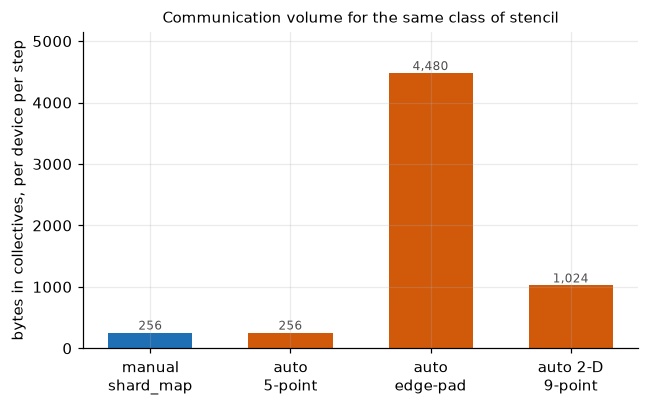

In [15]:
def bytes_moved(cs, itemsize=8):
    total = 0
    for c in cs:
        dims = [int(d) for d in re.search(r"\[([0-9,]*)\]", c).group(1).split(",") if d]
        n = 1
        for d in dims:
            n *= d
        total += n * itemsize
    return total


with jax.sharding.set_mesh(emesh):
    manual_cs = collectives_in(manual.lower(ex).compile().as_text())

labels = ["manual\nshard_map", "auto\n5-point", "auto\nedge-pad", "auto 2-D\n9-point"]
vals = [bytes_moved(manual_cs),
        bytes_moved(collectives(five_point, field, out_shardings=sharding)),
        bytes_moved(collectives(neumann, field, out_shardings=sharding)),
        bytes_moved(collectives(nine_point, field2, out_shardings=sh2))]

fig, ax = plt.subplots(figsize=(6.0, 3.8))
ax.bar(labels, vals, color=[BLUE, ORANGE, ORANGE, ORANGE], width=0.6)
ax.set_ylabel("bytes in collectives, per device per step")
ax.set_title("Communication volume for the same class of stencil", fontsize=10)
for i, v in enumerate(vals):
    ax.annotate(f"{v:,}", (i, v), ha="center", va="bottom", fontsize=8, color="0.3")
ax.margins(y=0.15)
fig.tight_layout()
plt.show()

The first three bars are the same 64×16 array on the same 8-device mesh and are directly
comparable. Manual and automatic land on **the same 256 bytes** — the hand-written halo
wins nothing on volume. The edge-padded version is the outlier, about 17× worse.

The fourth bar is a *different* problem (64×32 on a 4×2 mesh, twice the neighbours), so it
is not like-for-like; it is here only to show corners cost a factor of two, not of ten.

Two health warnings. These are **per-device** counts read out of the SPMD module —
machine-wide, multiply by the device count. And bytes are a proxy that ignores latency,
which for messages this small usually dominates. A scheme moving the same bytes in fewer
messages can be much faster.

## 9b. Composed stencils: `lap(lap(u))`

A second-order operator needs a halo two cells wide. Since every `roll` is lowered
independently, the natural worry is that composing stencils makes communication blow up.

In [16]:
def compose(f, n):
    def g(z):
        for _ in range(n):
            z = f(z)
        return z
    return g


print(f"{'depth':>6} {'messages':>9} {'widths':>34} {'bytes':>7}")
for n in (1, 2, 3, 4):
    cs = collectives(compose(five_point, n), field, out_shardings=sharding)
    widths = {}
    for c in cs:
        widths[c] = widths.get(c, 0) + 1
    print(f"{n:>6} {len(cs):>9} {str(widths):>34} {bytes_moved(cs):>7}")

 depth  messages                             widths   bytes


     1         2    {'collective-permute[1,16]': 2}     256


     2         4    {'collective-permute[1,16]': 4}     512
     3         6    {'collective-permute[1,16]': 6}     768


     4         8    {'collective-permute[1,16]': 8}    1024


It does not blow up: `lap^n` costs `2n` messages of width one, linear in depth. And the
**total bytes are already optimal** — 2n rows is exactly what two width-`n` exchanges would
move.

What is *not* optimal is the message count, and worse, those messages are **sequential**.
Exchange `k` carries the output of stencil `k-1`, so it cannot start until that stencil has
finished. `lap⁴` pays four dependent latency hits per direction where one would do, and at
these message sizes latency is most of the cost.

The alternative every hand-written stencil code uses is **halo widening with redundant
computation**: exchange width `n` once, then evaluate `lap` on progressively shrinking
extended domains so levels 2..n need no communication at all. One round trip, some wasted
flops in the halo.

Could a compiler do that for you? All the information is statically available — the stencil
extents and the dependence structure are known. But it is not a peephole on the collectives,
and here is why: **the two exchanges are not two slices of the same array.** The second one
moves the *result* of the first stencil. You cannot merge the sends without also changing
*what is computed where*, recomputing `lap` redundantly across the halo. That is an
iteration-domain transformation — the stencil literature calls it overlapped tiling or
ghost-zone expansion — and flat dataflow HLO is the wrong level to express it: by the time
`collective-permute` exists, the iteration domains have been lowered away.

A stencil DSL sits at exactly the right level, which is why GT4Py does domain inference and
extends the compute domains of temporaries. This is a concrete case of the DSL knowing
something the general-purpose compiler structurally cannot.

## 10. Mixing modes

The modes are not all-or-nothing. Inside Explicit code you can drop a region into Auto and
let the compiler handle it, and vice versa.

In [17]:
from jax.sharding import auto_axes

with jax.sharding.set_mesh(emesh):
    rolled = jax.jit(lambda a: auto_axes(lambda b: jnp.roll(b, 1, 0),
                                         out_sharding=P("x", None), axes="x")(a))
    print("roll inside auto_axes  :", collectives_in(rolled.lower(ex).compile().as_text()))
    print("result matches roll    :", bool(jnp.allclose(rolled(ex), jnp.roll(np.asarray(ex), 1, 0))))

print("\navailable escape hatches:",
      [n for n in ("auto_axes", "explicit_axes", "reshard") if hasattr(jax.sharding, n)])

roll inside auto_axes  : ['collective-permute[1,16]']
result matches roll    : True

available escape hatches: ['auto_axes', 'explicit_axes', 'reshard']


`auto_axes` is the pragmatic answer when Explicit mode rejects something you know is fine:
it re-enables GSPMD inference for that block only, and reproduces the Auto result exactly —
one `collective-permute[1,16]`, the same minimal halo.

## 11. Differentiating through it

This is why `nb02` cared. Sharding composes with `jax.grad`: the collectives have transpose
rules, so reverse mode walks through them and produces a correctly-sharded gradient.

| forward collective | its transpose |
|---|---|
| `ppermute(perm)` | `ppermute(inverse perm)` |
| `psum` | `pvary` / `psum` |
| `all_gather` | `psum_scatter` |
| `psum_scatter` | `all_gather` |

`all_gather` and `psum_scatter` being each other's transpose is the one people find
surprising, and it is the same fact as `nb01`'s: **the transpose of a gather is a
scatter-with-accumulation.**

In [18]:
weights = jax.device_put(
    jnp.asarray(np.random.default_rng(0).standard_normal((NX, NY))), esharding)

with jax.sharding.set_mesh(emesh):
    grad_manual = jax.jit(jax.grad(lambda z: jnp.sum(manual(z) * weights)))
    g = grad_manual(ex)
    gcs = collectives_in(grad_manual.lower(ex).compile().as_text())

w_np = np.asarray(weights)
g_ref = jax.grad(lambda z: jnp.sum(five_point(z) * w_np))(jnp.asarray(single))

print("backward-pass collectives :", gcs)
print("gradient sharding kept    :", g.sharding.spec)
print("matches single device     :", bool(jnp.allclose(g, g_ref)),
      "| max diff", float(jnp.max(jnp.abs(g - g_ref))))

backward-pass collectives : ['collective-permute[1,16]', 'collective-permute[1,16]']
gradient sharding kept    : P('x', None)
matches single device     : True | max diff 1.7763568394002505e-15


The backward pass contains its own `collective-permute`s — the reverse halo exchange,
derived rather than written — and the gradient agrees with the single-device answer to
roundoff while staying sharded.

## 12. Multiple processes

Everything so far ran in **one process** driving eight devices. At scale that is not the
arrangement: you get one process per node (or per GPU), each holding a few devices, and

- every process runs **the same program**,
- `jax.distributed.initialize()` forms the process group,
- `jax.device_count()` is global, `jax.local_device_count()` is this process's share,
- a global `jax.Array` is *not* fully addressable — `.addressable_shards` gives you only
  the local pieces. Indexing a remote element still *works*, because it compiles to an
  SPMD collective every process runs; what raises is pulling the whole array back to the
  host (`np.asarray`). The corollary is a deadlock hazard: such a read is collective, so
  **every** process must execute it or the ones that do will hang,
- `jax.make_array_from_process_local_data` builds a global array from per-process blocks.

Bootstrapping is automatic under Slurm, Open MPI, or `mpi4py` — see
`jax/_src/clusters/`. That detection only establishes *who is in the group*; it is not the
transport (section 13).

The script below is a real two-process run, launched from this notebook:

In [19]:
script = '''
import sys, os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import jax, jax.numpy as jnp, numpy as np
pid, n = int(sys.argv[1]), int(sys.argv[2])
jax.distributed.initialize(coordinator_address="localhost:29511",
                           num_processes=n, process_id=pid, local_device_ids=[0])
from jax.sharding import NamedSharding, PartitionSpec as P, AxisType
mesh = jax.make_mesh((n,), ("x",), axis_types=(AxisType.Auto,))
sh = NamedSharding(mesh, P("x", None))
print(f"[{pid}] global devices={jax.device_count()} local={jax.local_device_count()}", flush=True)
g = jax.make_array_from_process_local_data(sh, np.full((4, 3), float(pid)))
out = jax.jit(lambda a: jnp.roll(a, 1, axis=0), out_shardings=sh)(g)
print(f"[{pid}] fully addressable: {out.is_fully_addressable}", flush=True)
print(f"[{pid}] local shard after ring shift:\\n{np.asarray(out.addressable_shards[0].data)}", flush=True)
jax.distributed.shutdown()
'''
import tempfile, pathlib

tmpdir = tempfile.mkdtemp(prefix="jax_mp_")
demo = pathlib.Path(tmpdir) / "mp_halo_demo.py"      # not written into the repo
demo.write_text(script)

import subprocess, sys

# Each process must own exactly ONE device, so override the 8-fake-device XLA_FLAGS
# this notebook set at import time -- otherwise every process makes 8 and the mesh is wrong.
child_env = dict(os.environ, XLA_FLAGS="--xla_force_host_platform_device_count=1")
procs = [subprocess.Popen([sys.executable, str(demo), str(i), "2"],
                          stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
                          env=child_env)
         for i in range(2)]
for p in procs:
    try:
        out, _ = p.communicate(timeout=300)
    except subprocess.TimeoutExpired:
        p.kill()
        out, _ = p.communicate()
        out += "\n(timed out -- rendezvous never completed)"
    print("\n".join(l for l in out.splitlines() if not l.startswith("An NVIDIA")))

[0] global devices=2 local=1
[Gloo] Rank 0 is connected to 1 peer ranks. Expected number of connected peer ranks is : 1
[0] fully addressable: False
[0] local shard after ring shift:
[[1. 1. 1.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[1] global devices=2 local=1
[Gloo] Rank 1 is connected to 1 peer ranks. Expected number of connected peer ranks is : 1
[1] fully addressable: False
[1] local shard after ring shift:
[[0. 0. 0.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


The global array is 8×3: rows 0–3 owned by process 0 (all zeros), rows 4–7 by process 1
(all ones). After a ring shift of one row, global row 0 should hold what was in row 7 — a
value that lives *in the other process*. Process 0's local shard comes back as
`[1, 0, 0, 0]` and process 1's as `[0, 1, 1, 1]`, which is exactly right. That single `1`
at the top of process 0's block crossed a process boundary; it is a halo exchange over a
socket.

Note also `is_fully_addressable: False` — the array exists, but no single process holds all
of it, and that is the defining property of the multi-process world.

## 13. What actually carries the bytes

`shard_map` and `ppermute` are a programming model; they lower to XLA collectives, and
**XLA** chooses the transport per platform.

| platform | transport | selectable? |
|---|---|---|
| GPU (NVIDIA) | **NCCL** | no |
| GPU (AMD) | RCCL | no |
| TPU | ICI, hardware collectives | no |
| CPU | **gloo** (default) or **MPI** | `jax_cpu_collectives_implementation` |

Two independent uses of MPI are easy to conflate:

- `jax/_src/clusters/{mpi4py,ompi,slurm}_cluster.py` — **bootstrap only**. Discovers rank,
  size and coordinator address so `jax.distributed.initialize()` can form the group.
- `jax_cpu_collectives_implementation="mpi"` — the **actual transport**, and CPU only.

So launching under `mpirun` does not mean your `ppermute` travels over MPI. On GPU it goes
over NCCL regardless. For a model with an existing MPI/GHEX communication layer this is the
decisive constraint, and it is exactly why `nb02` has a Route B at all: if JAX must own the
transport, it must also own the decomposition.

In [20]:
print("CPU collectives implementation:", jax.config.jax_cpu_collectives_implementation)

CPU collectives implementation: gloo


## Where this connects

- **`nb01_halo_exchange_adjoint.ipynb`** — the adjoint of a halo exchange in GT4Py's field
  view. Section 11 above is the distributed-array counterpart of its central claim: the
  transpose of a gather is a scatter-with-accumulation.
- **`nb02_distributed_ad.ipynb`** — uses `shard_map` + `ppermute` (Route A) and MPI +
  `custom_vjp` (Route B). Sections 7 and 13 here explain why those are the two options and
  not one.
- **GT4Py.** Nothing above knows about GT4Py. Combining them means running GT4Py field
  operators *inside* `shard_map` on the local block, which is exactly what `nb02` does —
  the local domain becomes the GT4Py domain, and `ppermute` supplies the halo.

### References

- JAX parallel-programming guide: https://docs.jax.dev/en/latest/parallel.html
- `shard_map` reference: https://docs.jax.dev/en/latest/notebooks/shard_map.html
- Multi-process guide: https://docs.jax.dev/en/latest/multi_process.html
- Explicit sharding / axis types: https://docs.jax.dev/en/latest/notebooks/explicit-sharding.html
- GSPMD: Xu et al., *GSPMD: General and Scalable Parallelization for ML Computation Graphs*, arXiv:2105.04663, 2021.